# (노트) Boxplot 
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [파이썬]

### Ref

https://matplotlib.org/3.1.1/gallery/pyplots/boxplot_demo_pyplot.html#sphx-glr-gallery-pyplots-boxplot-demo-pyplot-py

### import

In [8]:
import matplotlib.pyplot as plt 
import numpy as np

### Boxplot 

#### 평균은 괜찮은 측정값인가? (통계학과)

`-` 통계학을 수업하는 두 선생님이 있다. 편의상 A 선생님과 B 선생님이라고 하자. A 선생님이 강의한 반의 통계학 점수는 평균 79.1점, B 선생님이 강의한 반의 통계학 점수는 평균 78.3점 이라고 하자. 

`-` 의사결정: A 선생님에게 배운 학생들의 실력이 평균적으로 좋을것이다.

In [9]:
y1=[75,75,76,76,77,77,79,79,79,98] ## A 선생님에게 통계학을 배운 학생의 점수들
y2=[76,76,77,77,78,78,80,80,80,81] ## B 선생님에게 통계학을 배운 학생의 점수들 

In [10]:
np.mean(y1), np.mean(y2)

(79.1, 78.3)

`-` 평균은 A반(=A선생님에게 통계학을 배운 반)이 더 높다. 그런데 98점을 받은 학생때문에 전체 평균이 올라간것이지 나머지 학생들은 모두 B반(=B선생님에게 통계학을 배운 반) 학생들의 점수가 더 높다. 

`-` 단순한 평균비교보다 분포를 비교하는것이 중요함. 분포를 살펴보는 방법중 하나로는 박스플랏이 있다. 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f63881c9eb0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f63881c9550>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f63881ccd00>],
 'medians': [<matplotlib.lines.Line2D at 0x7f63881c4550>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f63881c4760>],
 'means': []}

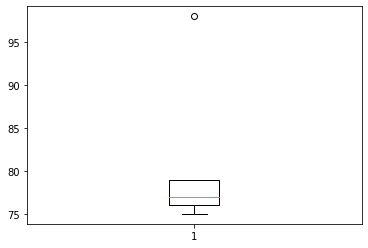

In [11]:
plt.boxplot(y1)

- A반의 boxplot
- 뚝 떨어진 하나의 점은 98점 
- 붉은 선은 중앙값 (평균이 아니라 중앙값) 
- 나머지 점들은 7~80점에 분포되어있다. 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f6386868bb0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f638687b310>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f6386868820>],
 'medians': [<matplotlib.lines.Line2D at 0x7f638687ba30>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f638687bdc0>],
 'means': []}

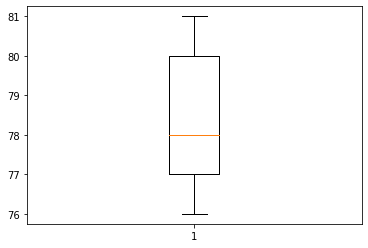

In [12]:
plt.boxplot(y2)

- B반의 boxplot

`-` 따로따로 그리는것은 별로 좋지않은 시각화 방법같다. (한눈에 보이지 않음, y축의 scale도 다름)

`-` 아래와 같이 개선해보자. 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f638685ca60>,
 'caps': [<matplotlib.lines.Line2D at 0x7f63867eb1c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f638685c6d0>,
 'medians': [<matplotlib.lines.Line2D at 0x7f63867eb8e0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f63867ebc70>,
 'means': []}

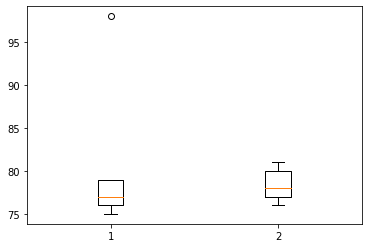

In [13]:
plt.boxplot([y1,y2])

`-` 미적인 요소가 아쉽긴 하지만 이정도는 괜찮다. 

#### 박스플랏 기초 (통계학과)

`-` ref: https://towardsdatascience.com/understanding-boxplots-5e2df7bcbd51
 - github: https://github.com/mGalarnyk/Python_Tutorials/blob/master/Statistics/boxplot/box_plot.ipynb

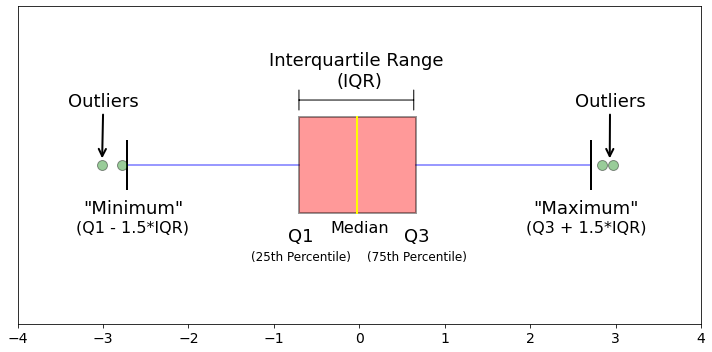

In [56]:
#collapse
np.random.seed(916170)

# connection path is here: https://stackoverflow.com/questions/6146290/plotting-a-line-over-several-graphs
mu, sigma = 0, 1 # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)

fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize=(10, 5))

# rectangular box plot
bplot = axes.boxplot(s,
                vert=False,
                patch_artist=True, 
                showfliers=True, # This would show outliers (the remaining .7% of the data)
                positions = [0],
                boxprops = dict(linestyle='--', linewidth=2, color='Black', facecolor = 'red', alpha = .4),
                medianprops = dict(linestyle='-', linewidth=2, color='Yellow'),
                whiskerprops = dict(linestyle='-', linewidth=2, color='Blue', alpha = .4),
                capprops = dict(linestyle='-', linewidth=2, color='Black'),
                flierprops = dict(marker='o', markerfacecolor='green', markersize=10,
                  linestyle='none', alpha = .4),
                widths = .3,
                zorder = 1)   

axes.set_xlim(-4, 4)
plt.xticks(fontsize = 14)

axes.set_yticks([])
axes.annotate(r'',
            xy=(-.73, .205), xycoords='data',
            xytext=(.66, .205), textcoords='data',
            arrowprops=dict(arrowstyle="|-|",
                            connectionstyle="arc3")
            );

axes.text(0, .25, "Interquartile Range \n(IQR)",  horizontalalignment='center', fontsize=18)
axes.text(0, -.21, r"Median", horizontalalignment='center', fontsize=16);
axes.text(2.65, -.15, "\"Maximum\"", horizontalalignment='center', fontsize=18);
axes.text(-2.65, -.15, "\"Minimum\"", horizontalalignment='center', fontsize=18);
axes.text(-.68, -.24, r"Q1", horizontalalignment='center', fontsize=18);
axes.text(-2.65, -.21, r"(Q1 - 1.5*IQR)", horizontalalignment='center', fontsize=16);
axes.text(.6745, -.24, r"Q3", horizontalalignment='center', fontsize=18);
axes.text(.6745, -.30, r"(75th Percentile)", horizontalalignment='center', fontsize=12);
axes.text(-.68, -.30, r"(25th Percentile)", horizontalalignment='center', fontsize=12);
axes.text(2.65, -.21, r"(Q3 + 1.5*IQR)", horizontalalignment='center', fontsize=16);

axes.annotate('Outliers', xy=(2.93,0.015), xytext=(2.52,0.20), fontsize = 18,
            arrowprops={'arrowstyle': '->', 'color': 'black', 'lw': 2},
            va='center');

axes.annotate('Outliers', xy=(-3.01,0.015), xytext=(-3.41,0.20), fontsize = 18,
            arrowprops={'arrowstyle': '->', 'color': 'black', 'lw': 2},
            va='center');

fig.tight_layout()

#### plotly (컴퓨터공학과)

In [48]:
import plotly.express as px
from IPython.display import HTML
import pandas as pd

In [49]:
A=pd.DataFrame({'y':y1,'x':['A']*len(y1)})
B=pd.DataFrame({'y':y2,'x':['B']*len(y2)})
df=pd.concat([A,B])

In [50]:
df

,y,x
0,75,A
1,75,A
2,76,A
3,76,A
4,77,A
5,77,A
6,79,A
7,79,A
8,79,A
9,98,A


In [51]:
fig=px.box(data_frame=df,x='x',y='y')
HTML(fig.to_html(include_plotlyjs='cdn',include_mathjax=False))